<a href="https://colab.research.google.com/github/r-pranav-git/MetalDefectSSL/blob/main/02_simclr_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SimCLR Self-Supervised Learning for Metal Surface Defect Classification

This notebook implements the self-supervised SimCLR stage of the research methodology using the NEU-DET dataset.

Pipeline:

NEU-DET → Augmentation → Two Views → Encoder → Representation → Projection Head → NT-Xent Contrastive Loss

**Import the required libraries**

In [1]:
import os
import glob
import random

import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## 1. Load NEU-DET Dataset

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**Dataset path**

In [11]:
dataset_path = "/content/drive/MyDrive/NEU-DET/train/images"

print("Dataset path:", dataset_path)

Dataset path: /content/drive/MyDrive/NEU-DET/train/images


Verify dataset

In [12]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

image_paths = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))

if len(image_paths) > 0:
    print("First image:", image_paths[0])

Total images found: 1440
First image: /content/drive/MyDrive/NEU-DET/train/images/pitted_surface/pitted_surface_158.jpg


Look at one image

Image shape: (200, 200, 3)


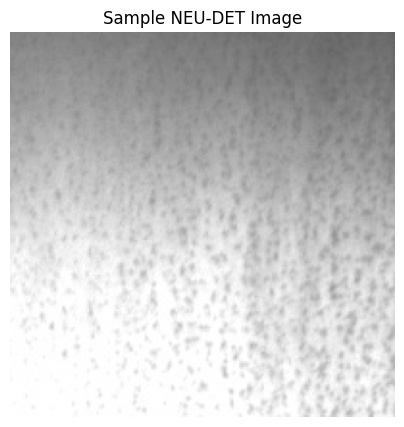

In [13]:
sample_image = cv2.imread(image_paths[0])

sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

print("Image shape:", sample_image.shape)

plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.axis("off")
plt.title("Sample NEU-DET Image")
plt.show()

SimCLR augmentation

## 2. SimCLR Augmentation Pipeline

For each original image, two different augmented views are generated.

The two views are treated as a positive pair during contrastive learning.

In [14]:
simclr_transform = transforms.Compose([
    transforms.ToPILImage(),

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4,
        hue=0.1
    ),

    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=23)],
        p=0.5
    ),

    transforms.ToTensor()
])

Generate two views

In [15]:
image = cv2.imread(image_paths[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

view1 = simclr_transform(image)
view2 = simclr_transform(image)

print("View 1 shape:", view1.shape)
print("View 2 shape:", view2.shape)

View 1 shape: torch.Size([3, 224, 224])
View 2 shape: torch.Size([3, 224, 224])


Visualize the two views

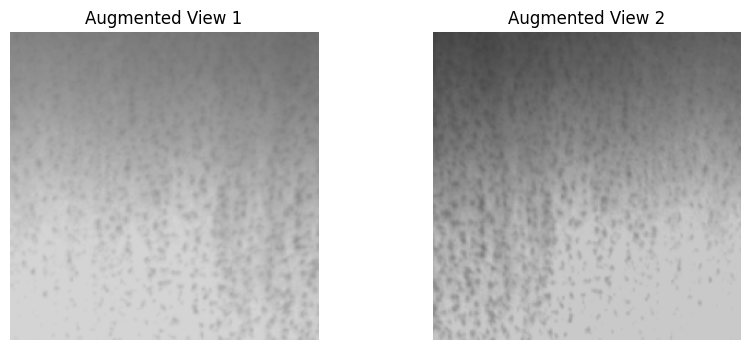

In [16]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(view1.permute(1, 2, 0))
plt.title("Augmented View 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(view2.permute(1, 2, 0))
plt.title("Augmented View 2")
plt.axis("off")

plt.show()

Create SimCLR Dataset

## 3. SimCLR Dataset

The dataset generates two independently augmented views from each original image.

In [17]:
class SimCLRDataset(Dataset):

    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        view1 = self.transform(image)
        view2 = self.transform(image)

        return view1, view2

Create dataset

In [18]:
simclr_dataset = SimCLRDataset(
    image_paths=image_paths,
    transform=simclr_transform
)

print("Number of samples:", len(simclr_dataset))

Number of samples: 1440


Create DataLoader

In [19]:
batch_size = 32

simclr_loader = DataLoader(
    simclr_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Batch size:", batch_size)

Batch size: 32


Check one batch

In [20]:
view1_batch, view2_batch = next(iter(simclr_loader))

print("View 1 batch shape:", view1_batch.shape)
print("View 2 batch shape:", view2_batch.shape)

View 1 batch shape: torch.Size([32, 3, 224, 224])
View 2 batch shape: torch.Size([32, 3, 224, 224])
